In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# optencion de datos de una api

utilzando la libreria de request para la optencion de los datos de origen

In [2]:
url = 'https://randomuser.me/api/?results=300&nat=us'

response = requests.get(url)
data =response.json()['results']

# Creacion del dataset
utilizando pandas


In [3]:
df = pd.json_normalize(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   gender                          300 non-null    object
 1   email                           300 non-null    object
 2   phone                           300 non-null    object
 3   cell                            300 non-null    object
 4   nat                             300 non-null    object
 5   name.title                      300 non-null    object
 6   name.first                      300 non-null    object
 7   name.last                       300 non-null    object
 8   location.street.number          300 non-null    int64 
 9   location.street.name            300 non-null    object
 10  location.city                   300 non-null    object
 11  location.state                  300 non-null    object
 12  location.country                300 non-null    ob

In [4]:
df = df[['gender', 'dob.age', 'location.city', 'location.state']]
# tarea 1 renombrar
df = df.rename(columns={'dob.age': 'age', 'location.city': 'city', 'location.state': 'state'})

print(f"Mdedida de Tendencia central:{df.describe()}")

Mdedida de Tendencia central:              age
count  300.000000
mean    52.086667
std     15.411821
min     25.000000
25%     39.000000
50%     51.500000
75%     65.000000
max     81.000000


In [5]:
df

,gender,age,city,state
0,female,71,Toledo,Arizona
1,male,49,Cedar Rapids,Utah
2,female,49,Lewisville,Maryland
3,male,37,Nampa,Ohio
4,male,60,Antioch,Louisiana
...,...,...,...,...
295,female,48,Fort Wayne,Iowa
296,female,58,Manchester,Massachusetts
297,female,61,Westminster,New Hampshire
298,female,55,Ironville,Montana


gender
male      159
female    141
Name: count, dtype: int64


/tmp/ipython-input-4166779023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette="Set3")


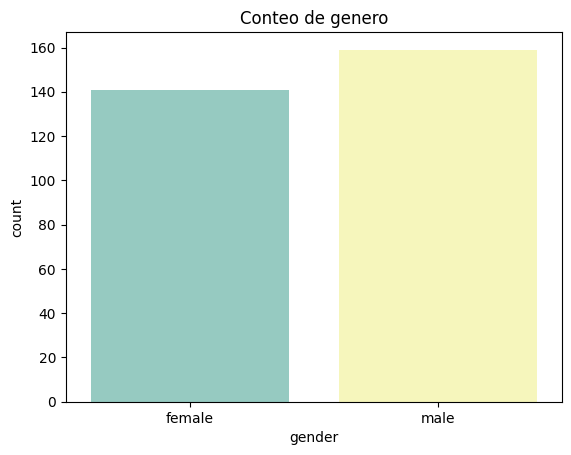

In [6]:
print(f"{df['gender'].value_counts()}")
sns.countplot(x='gender', data=df, palette="Set3")
plt.title('Conteo de genero')
plt.show()


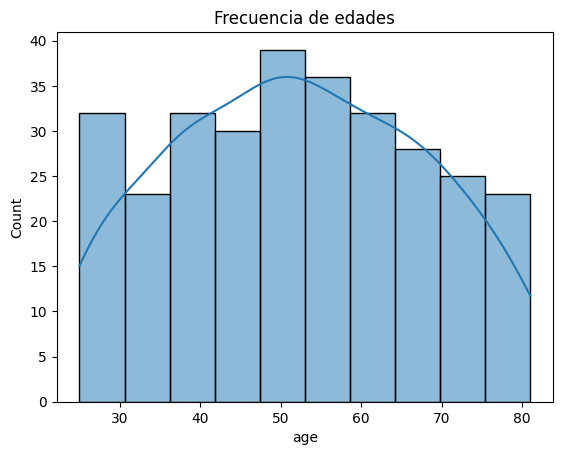

In [7]:
# tarea 2 visualizacion de frecuencias de edades
sns.histplot(x='age', data=df, kde=True)
plt.title('Frecuencia de edades')
plt.show()